# SegFormer-B0 on DRIVE (Binary Segmentation)

- Transfer learning with pretrained SegFormer-B0
- AdamW optimizer
- Early stopping on validation Dice or IoU
- Saves best model to best_segformer_b0.pth

In [1]:
!pip -q install transformers timm albumentations opencv-python tqdm pandas matplotlib

In [2]:
from pathlib import Path
import os
import sys

REPO_URL = "https://github.com/KhanhGiauTen/DL-retinal-vessel-segmentation-final.git"
REPO_DIR = Path("/kaggle/working/DL-retinal-vessel-segmentation-final")

if not REPO_DIR.exists():
    !git clone {REPO_URL} {REPO_DIR}

os.chdir(REPO_DIR)
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

print("Using repo:", REPO_DIR)
print("CWD:", Path.cwd())

Cloning into '/kaggle/working/DL-retinal-vessel-segmentation-final'...
remote: Enumerating objects: 117, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 117 (delta 29), reused 38 (delta 15), pack-reused 55 (from 1)
Receiving objects: 100% (117/117), 73.41 MiB | 45.67 MiB/s, done.
Resolving deltas: 100% (47/47), done.
Using repo: /kaggle/working/DL-retinal-vessel-segmentation-final
CWD: /kaggle/working/DL-retinal-vessel-segmentation-final


In [3]:
import os
from pathlib import Path
import random
import zipfile

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [4]:
DATA_DIR = Path("/kaggle/input/datasets/khnhnguyn222/drive-processed-dataset")  # update dataset slug if needed
ZIP_PATH = DATA_DIR / "DRIVE_processed_dataset.zip"
WORK_DIR = Path("/kaggle/working")
EXTRACT_DIR = WORK_DIR / "DRIVE_processed_dataset"

IMG_SIZE = 512
BATCH_SIZE = 4
NUM_EPOCHS = 50
LR = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 10
BEST_METRIC = "dice"
AMP = torch.cuda.is_available()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BEST_MODEL_PATH = WORK_DIR / "best_segformer_b0.pth"
HISTORY_PATH = WORK_DIR / "segformer_b0_history.csv"
RESULTS_PATH = WORK_DIR / "segformer_b0_results.csv"
PREDICTIONS_DIR = WORK_DIR / "segformer_b0_predictions"

In [5]:
def resolve_processed_dataset_root(data_dir: Path, zip_path: Path, extract_dir: Path) -> Path:
    if zip_path.exists():
        if not extract_dir.exists() or not all((extract_dir / split).exists() for split in ("train", "val", "test")):
            extract_dir.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(extract_dir)

    for root in (extract_dir, data_dir):
        if all((root / split).exists() for split in ("train", "val", "test")):
            return root
        if root.exists():
            for child in root.iterdir():
                if child.is_dir() and all((child / split).exists() for split in ("train", "val", "test")):
                    return child

    raise FileNotFoundError(f"Could not find a processed DRIVE dataset root under {data_dir} or {extract_dir}.")

DATA_ROOT = resolve_processed_dataset_root(DATA_DIR, ZIP_PATH, EXTRACT_DIR)
print("DATA_ROOT:", DATA_ROOT)
print("train files:", len(list((DATA_ROOT / "train").glob("*.pt"))))

DATA_ROOT: /kaggle/input/datasets/khnhnguyn222/drive-processed-dataset
train files: 80


In [6]:
IMAGENET_MEAN_TENSOR = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(3, 1, 1)
IMAGENET_STD_TENSOR = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(3, 1, 1)

def prepare_segformer_image(image: torch.Tensor) -> torch.Tensor:
    image = image.float()
    if image.dim() != 3 or image.shape[0] != 3:
        raise ValueError(f"Expected image [3, H, W], got {tuple(image.shape)}")

    min_value = float(image.min())
    max_value = float(image.max())
    if min_value >= 0.0 and max_value > 1.0:
        image = image / 255.0
        image = (image - IMAGENET_MEAN_TENSOR) / IMAGENET_STD_TENSOR
    elif min_value >= 0.0 and max_value <= 1.0:
        image = (image - IMAGENET_MEAN_TENSOR) / IMAGENET_STD_TENSOR

    return image


class DriveProcessedDataset(Dataset):
    def __init__(self, root_dir: Path, split: str, img_size: int | None = None):
        self.root_dir = Path(root_dir)
        self.split = split
        self.files = sorted((self.root_dir / split).glob("*.pt"))
        self.img_size = img_size

    def __len__(self) -> int:
        return len(self.files)

    def __getitem__(self, idx: int):
        sample = torch.load(self.files[idx], map_location="cpu")
        image = sample.get("image")
        mask = sample.get("manual")
        if mask is None:
            mask = sample.get("manual_2")
        if mask is None:
            mask = sample.get("mask")

        if not torch.is_tensor(image):
            image = torch.tensor(image)
        if image.dim() == 3 and image.shape[0] != 3:
            image = image.permute(2, 0, 1)
        image = prepare_segformer_image(image)

        if not torch.is_tensor(mask):
            mask = torch.tensor(mask)
        mask = mask.float()
        if mask.dim() == 2:
            mask = mask.unsqueeze(0)
        elif mask.dim() == 3 and mask.shape[0] != 1:
            if mask.shape[-1] in (1, 3):
                mask = mask.permute(2, 0, 1)
            if mask.shape[0] != 1:
                mask = mask[:1]
        if mask.max() > 1.0:
            mask = mask / 255.0
        if mask.shape[0] != 1:
            raise ValueError(f"Expected mask [1, H, W], got {tuple(mask.shape)}")

        if self.img_size is not None:
            target_size = (self.img_size, self.img_size)
            if image.shape[-2:] != target_size:
                image = F.interpolate(
                    image.unsqueeze(0),
                    size=target_size,
                    mode="bilinear",
                    align_corners=False,
                ).squeeze(0)
            if mask.shape[-2:] != target_size:
                mask = F.interpolate(
                    mask.unsqueeze(0),
                    size=target_size,
                    mode="nearest",
                ).squeeze(0)

        return image, mask

train_ds = DriveProcessedDataset(DATA_ROOT, "train", img_size=IMG_SIZE)
val_ds = DriveProcessedDataset(DATA_ROOT, "val", img_size=IMG_SIZE)
test_ds = DriveProcessedDataset(DATA_ROOT, "test", img_size=IMG_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("train/val/test:", len(train_ds), len(val_ds), len(test_ds))

train/val/test: 80 4 20


In [7]:
from src.models.segformer import SegFormerB0

model = SegFormerB0(pretrained=True).to(DEVICE)

images, masks = next(iter(train_loader))
with torch.no_grad():
    logits = model(images.to(DEVICE))

expected_shape = (images.size(0), 1, images.size(2), images.size(3))
assert images.ndim == 4 and images.size(1) == 3, f"Expected input [B, 3, H, W], got {tuple(images.shape)}"
assert tuple(masks.shape) == expected_shape, f"Expected masks {expected_shape}, got {tuple(masks.shape)}"
assert tuple(logits.shape) == expected_shape, f"Expected logits {expected_shape}, got {tuple(logits.shape)}"
print("input:", images.shape, "masks:", masks.shape, "logits:", logits.shape)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([1, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([1])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


input: torch.Size([4, 3, 512, 512]) masks: torch.Size([4, 1, 512, 512]) logits: torch.Size([4, 1, 512, 512])


In [8]:
bce_loss = torch.nn.BCEWithLogitsLoss()

def dice_coef(logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    intersection = (probs * targets).sum(dim=(2, 3))
    denom = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3))
    dice = (2.0 * intersection + eps) / (denom + eps)
    return dice.mean()

def iou_score(logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    intersection = (probs * targets).sum(dim=(2, 3))
    union = probs.sum(dim=(2, 3)) + targets.sum(dim=(2, 3)) - intersection
    iou = (intersection + eps) / (union + eps)
    return iou.mean()

def bce_dice_loss(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    return bce_loss(logits, targets) + (1.0 - dice_coef(logits, targets))


class EarlyStopping:
    def __init__(self, patience: int = 10, min_delta: float = 0.0, mode: str = "max") -> None:
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.best_score = None
        self.counter = 0

    def step(self, score: float) -> bool:
        if self.best_score is None:
            self.best_score = score
            return False
        if self.mode == "max":
            improved = score > (self.best_score + self.min_delta)
        else:
            improved = score < (self.best_score - self.min_delta)
        if improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
        return self.counter >= self.patience


def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss = 0.0
    for images, masks in loader:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=AMP):
            logits = model(images)
            loss = bce_dice_loss(logits, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss = 0.0
    total_dice = 0.0
    total_iou = 0.0
    for images, masks in loader:
        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)
        logits = model(images)
        loss = bce_dice_loss(logits, masks)
        dice = dice_coef(logits, masks)
        iou = iou_score(logits, masks)
        total_loss += loss.item() * images.size(0)
        total_dice += dice.item() * images.size(0)
        total_iou += iou.item() * images.size(0)
    n = len(loader.dataset)
    return total_loss / n, total_dice / n, total_iou / n


def train_model(model, train_loader, val_loader):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scaler = torch.cuda.amp.GradScaler(enabled=AMP)
    early = EarlyStopping(patience=PATIENCE, min_delta=1e-4, mode="max")
    history = []
    best_score = -1.0
    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, scaler)
        val_loss, val_dice, val_iou = evaluate(model, val_loader)
        metric = val_dice if BEST_METRIC == "dice" else val_iou
        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_dice": val_dice,
            "val_iou": val_iou,
        })
        print(
            f"Epoch {epoch:03d} | train {train_loss:.4f} | val {val_loss:.4f} | ",
            f"dice {val_dice:.4f} | iou {val_iou:.4f}",
        )
        if metric > best_score + 1e-4:
            best_score = metric
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(f"Saved best model to {BEST_MODEL_PATH}")
        if early.step(metric):
            print("Early stopping triggered.")
            break
    return history


history = train_model(model, train_loader, val_loader)
history_df = pd.DataFrame(history)
history_df.to_csv(HISTORY_PATH, index=False)
print(f"Saved training history to {HISTORY_PATH}")
history_df.tail()

/tmp/ipykernel_23/42454273.py:84: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=AMP)
/tmp/ipykernel_23/42454273.py:52: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=AMP):


Epoch 001 | train 1.5300 | val 1.3952 |  dice 0.1751 | iou 0.0961
Saved best model to /kaggle/working/best_segformer_b0.pth
Epoch 002 | train 1.4041 | val 1.3202 |  dice 0.2047 | iou 0.1141
Saved best model to /kaggle/working/best_segformer_b0.pth
Epoch 003 | train 1.3083 | val 1.2422 |  dice 0.2392 | iou 0.1359
Saved best model to /kaggle/working/best_segformer_b0.pth
Epoch 004 | train 1.2189 | val 1.1403 |  dice 0.2519 | iou 0.1442
Saved best model to /kaggle/working/best_segformer_b0.pth
Epoch 005 | train 1.1490 | val 1.0847 |  dice 0.2712 | iou 0.1570
Saved best model to /kaggle/working/best_segformer_b0.pth
Epoch 006 | train 1.0945 | val 1.0126 |  dice 0.3026 | iou 0.1784
Saved best model to /kaggle/working/best_segformer_b0.pth
Epoch 007 | train 1.0423 | val 0.9473 |  dice 0.3255 | iou 0.1945
Saved best model to /kaggle/working/best_segformer_b0.pth
Epoch 008 | train 0.9938 | val 0.8941 |  dice 0.3543 | iou 0.2154
Saved best model to /kaggle/working/best_segformer_b0.pth
Epoch 00

,epoch,train_loss,val_loss,val_dice,val_iou
45,46,0.575877,0.466680,0.669368,0.503140
46,47,0.577427,0.465562,0.672980,0.507215
47,48,0.573290,0.467578,0.669165,0.502905
48,49,0.573140,0.465096,0.669400,0.503194
49,50,0.577017,0.469715,0.669653,0.503438


In [9]:
best_model = SegFormerB0(pretrained=False).to(DEVICE)
best_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))

val_loss, val_dice, val_iou = evaluate(best_model, val_loader)
test_loss, test_dice, test_iou = evaluate(best_model, test_loader)

best_idx = history_df["val_dice"].idxmax() if BEST_METRIC == "dice" else history_df["val_iou"].idxmax()
best_epoch = int(history_df.loc[best_idx, "epoch"])

results_df = pd.DataFrame([
    {"split": "val", "epoch": best_epoch, "loss": val_loss, "dice": val_dice, "iou": val_iou},
    {"split": "test", "epoch": best_epoch, "loss": test_loss, "dice": test_dice, "iou": test_iou},
])
results_df.to_csv(RESULTS_PATH, index=False)
print(f"Saved validation/test results to {RESULTS_PATH}")

results_df

Saved validation/test results to /kaggle/working/segformer_b0_results.csv


,split,epoch,loss,dice,iou
0,val,47,0.465562,0.67298,0.507215
1,test,47,0.458738,0.67677,0.511674


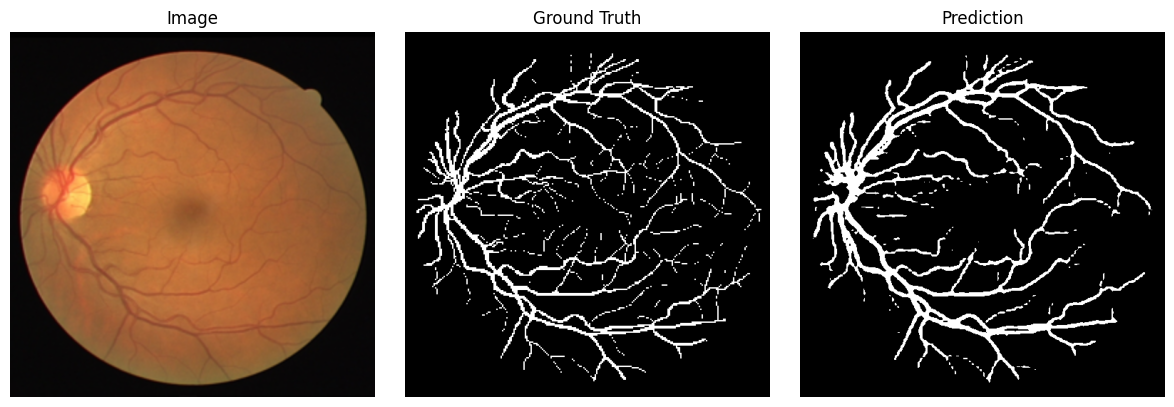

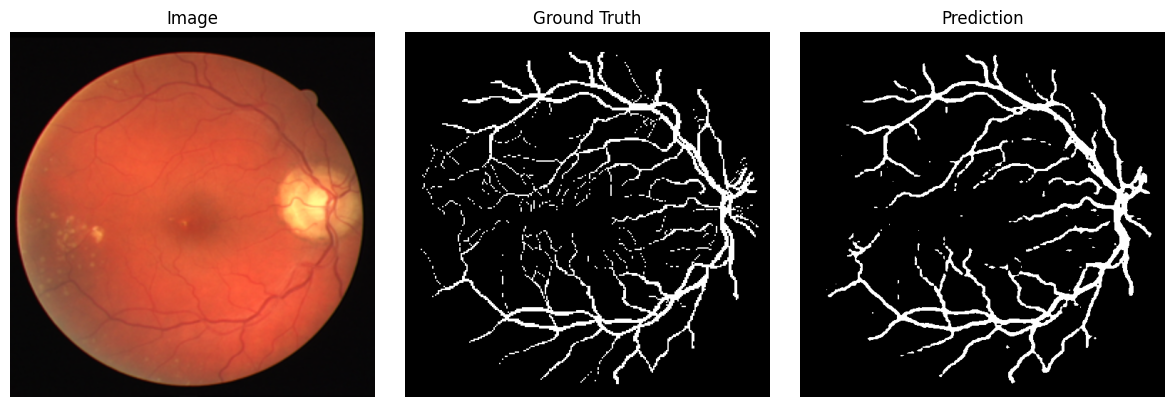

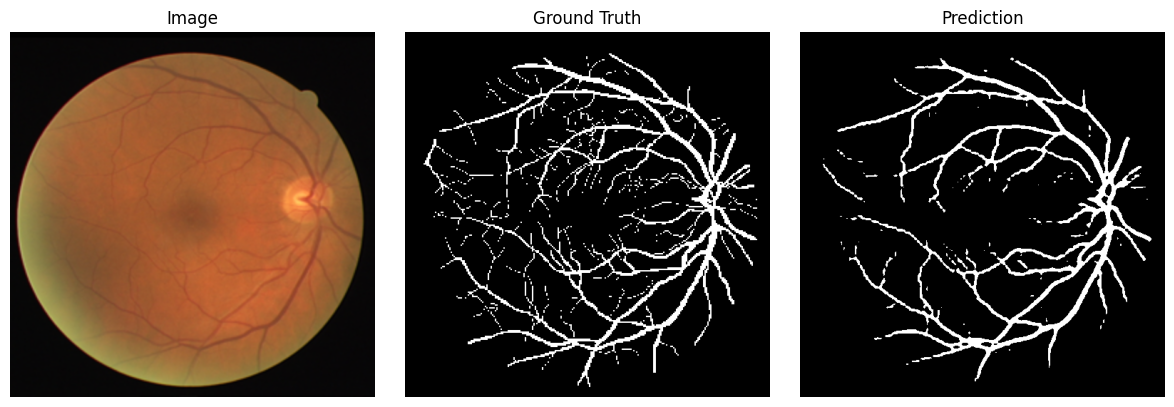

Saved 3 prediction figures to /kaggle/working/segformer_b0_predictions


[PosixPath('/kaggle/working/segformer_b0_predictions/prediction_000.png'),
 PosixPath('/kaggle/working/segformer_b0_predictions/prediction_017.png'),
 PosixPath('/kaggle/working/segformer_b0_predictions/prediction_015.png')]

In [10]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def denorm_image(img: torch.Tensor) -> np.ndarray:
    if img.dim() == 3 and img.shape[0] == 3:
        img = img.detach().cpu().numpy()
        img = img * IMAGENET_STD[:, None, None] + IMAGENET_MEAN[:, None, None]
        img = np.clip(img, 0.0, 1.0)
        img = np.transpose(img, (1, 2, 0))
        return img
    return img.detach().cpu().numpy()


def show_predictions(model, dataset, num_samples: int = 3):
    model.eval()
    PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
    num_samples = min(num_samples, len(dataset))
    idxs = np.random.choice(len(dataset), size=num_samples, replace=False)
    saved_paths = []
    for idx in idxs:
        sample_id = int(idx)
        image, mask = dataset[idx]
        with torch.no_grad():
            logits = model(image.unsqueeze(0).to(DEVICE))
            prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
            pred = (prob > 0.5).astype(np.float32)
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(denorm_image(image))
        axes[0].set_title("Image")
        axes[0].axis("off")
        axes[1].imshow(mask.squeeze(0).cpu().numpy(), cmap="gray")
        axes[1].set_title("Ground Truth")
        axes[1].axis("off")
        axes[2].imshow(pred, cmap="gray")
        axes[2].set_title("Prediction")
        axes[2].axis("off")
        plt.tight_layout()
        save_path = PREDICTIONS_DIR / f"prediction_{sample_id:03d}.png"
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        saved_paths.append(save_path)
        plt.show()
        plt.close(fig)
    print(f"Saved {len(saved_paths)} prediction figures to {PREDICTIONS_DIR}")
    return saved_paths


prediction_paths = show_predictions(best_model, test_ds, num_samples=3)
prediction_paths